In [ ]:
#Exploratory Data Analysis

In [1]:
import os
os.getcwd() ## for relaative path

'c:\\Users\\shiva\\Desktop\\Code\\AiMl\\1_EDA\\Titanic_CampusX'

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("sample_data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### Univariate Analysis

### Age
**Conclusions**
- Age is normally (almost) distributed
- 20% of the values are missing
- There are some outliers


In [9]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

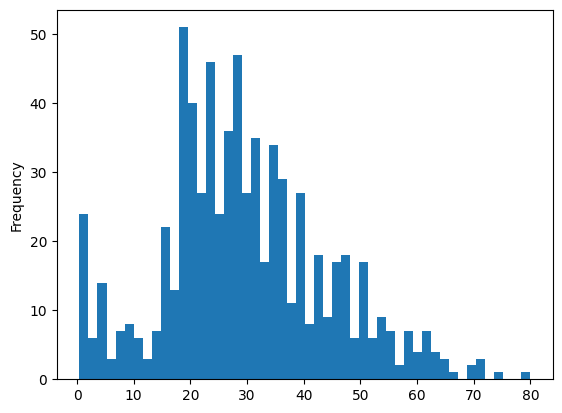

In [10]:
df['Age'].plot(kind='hist' , bins = 50)

<Axes: ylabel='Density'>

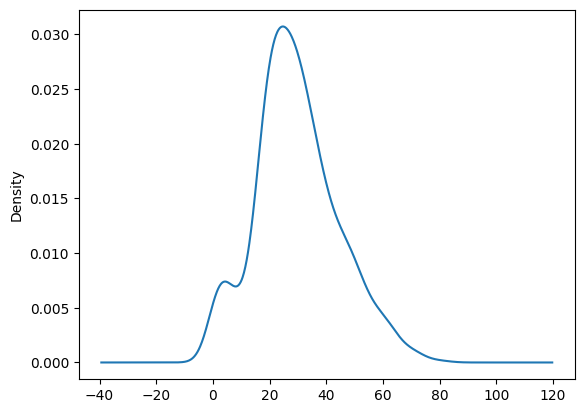

In [11]:
df['Age'].plot(kind='kde')

In [12]:
df['Age'].skew() 

# if its nearly zero then normal

np.float64(0.38910778230082704)

<Axes: >

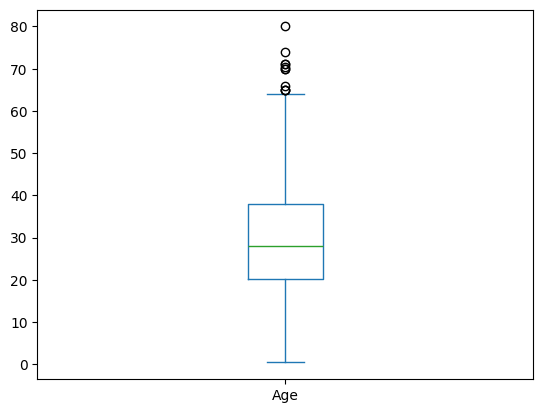

In [13]:
df['Age'].plot(kind='box')

In [14]:
df [df['Age'] > 65]
#outlier 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [15]:
df['Age'].isnull().sum() # total missing value

np.int64(177)

In [16]:
df['Age'].isnull().sum()/len(df['Age']) *100
# %age of missing values

np.float64(19.865319865319865)

### Fare
**Conclusion**
- The data is highly positively skewed
- Fare Colmn actually contains the group fare and not the individual fare(This might be an issue.)
- We need to create a new colmn called individual fare. 

In [17]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

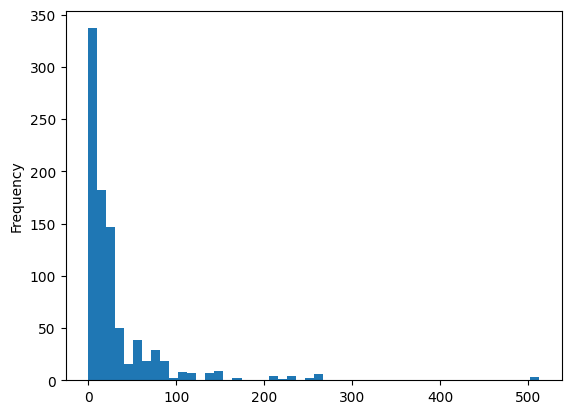

In [18]:
df['Fare'].plot(kind = 'hist' , bins=50)

<Axes: ylabel='Density'>

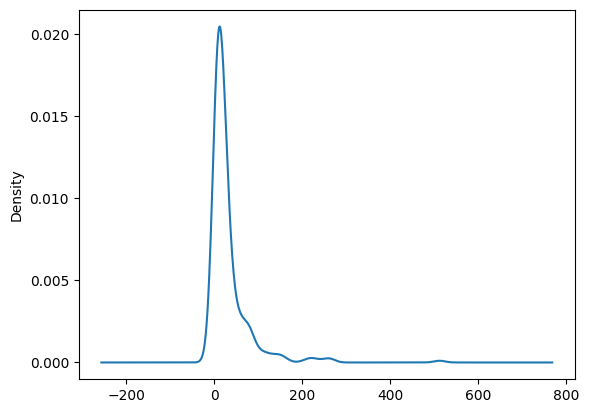

In [19]:
df['Fare'].plot(kind = 'kde')

In [20]:
df['Fare'].skew()
### Highly positively Skewed

np.float64(4.787316519674893)

<Axes: >

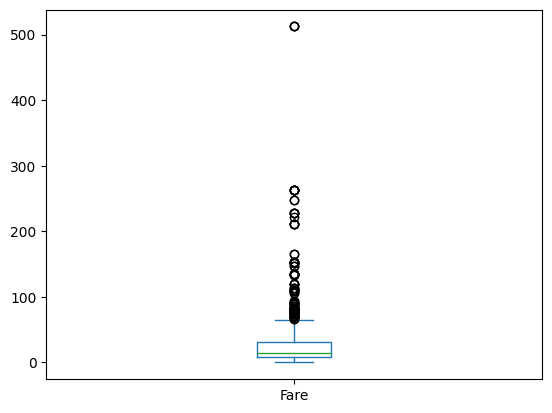

In [21]:
df['Fare'].plot(kind = 'box')
# Lots of outliers

In [22]:
df[df['Fare']>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [23]:
df['Fare'].isnull().sum()
# no missing value

np.int64(0)

### Survived Column

**Conclusions**
- Parch and SibSp colmns can be merged called Family_size
- Create a new column called is_alone

In [24]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

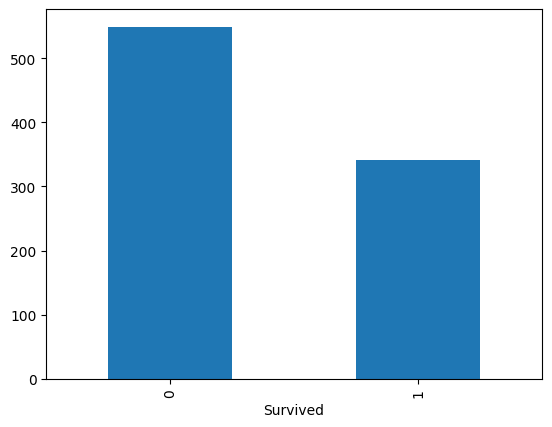

In [25]:
df['Survived'].value_counts().plot(kind = 'bar')

<Axes: >

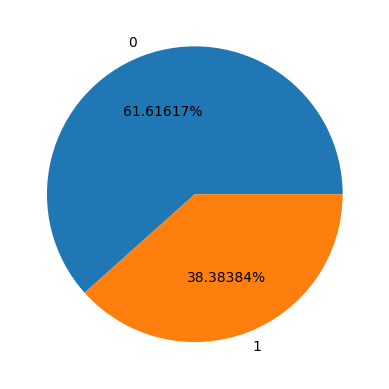

In [26]:
df['Survived'].value_counts().plot(kind = 'pie' , autopct ='%0.5f%%')

In [27]:
df['Survived'].isnull().sum()

np.int64(0)

In [28]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

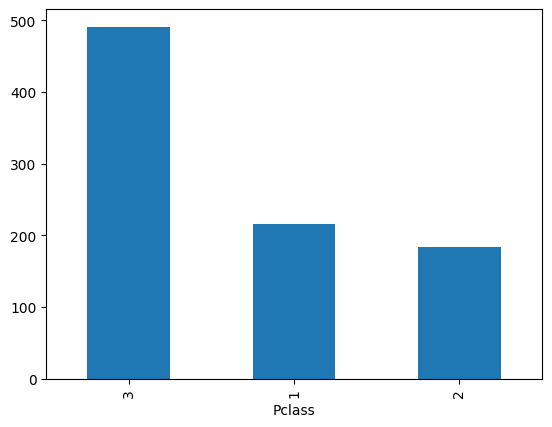

In [29]:
df['Pclass'].value_counts().plot(kind = 'bar')

<Axes: >

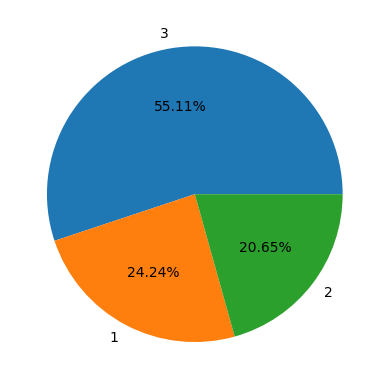

In [30]:
df['Pclass'].value_counts().plot(kind = 'pie' , autopct ='%0.2f%%')

In [31]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

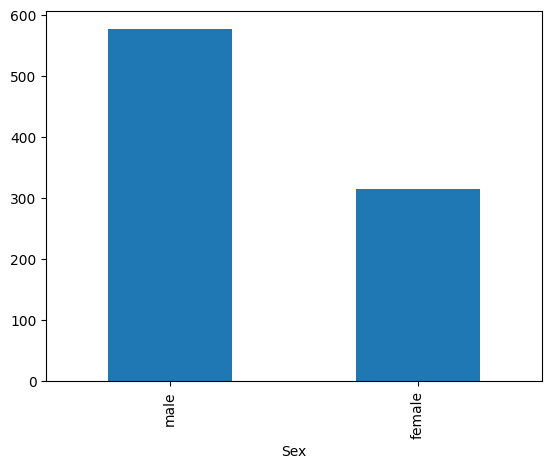

In [32]:
df['Sex'].value_counts().plot(kind = 'bar')

<Axes: >

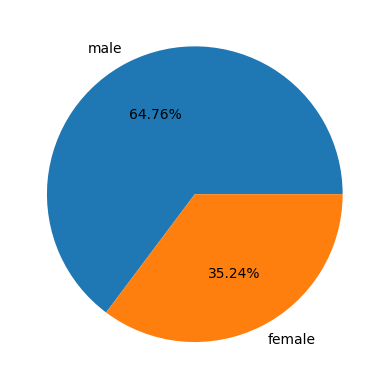

In [33]:
df['Sex'].value_counts().plot(kind = 'pie' , autopct ='%0.2f%%')

In [34]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

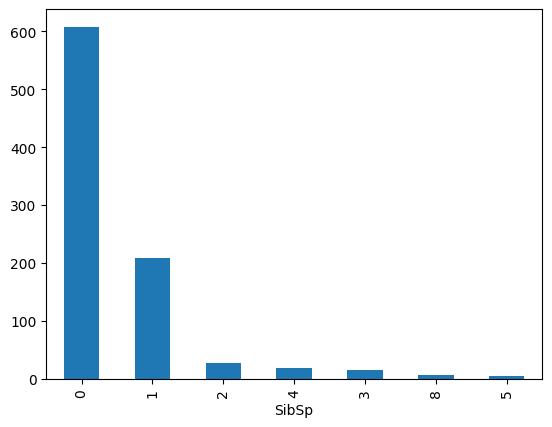

In [35]:
df['SibSp'].value_counts().plot(kind = 'bar' )

<Axes: >

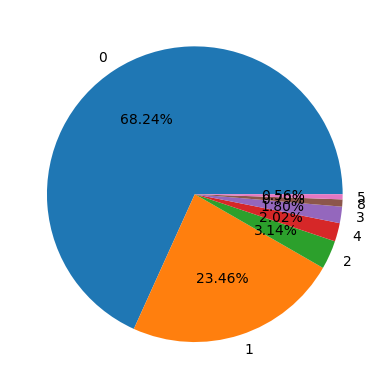

In [36]:
df['SibSp'].value_counts().plot(kind = 'pie' , autopct ='%0.2f%%')

In [37]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

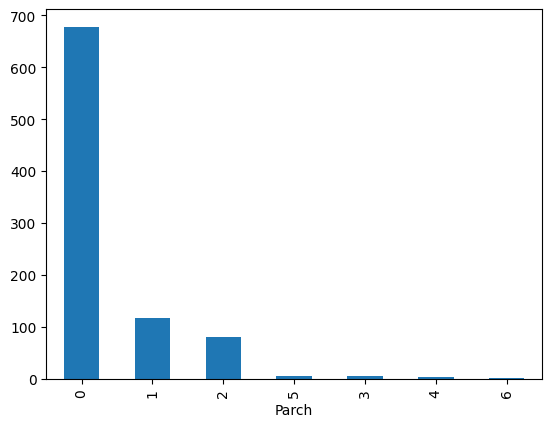

In [38]:
df['Parch'].value_counts().plot(kind = 'bar' )

<Axes: >

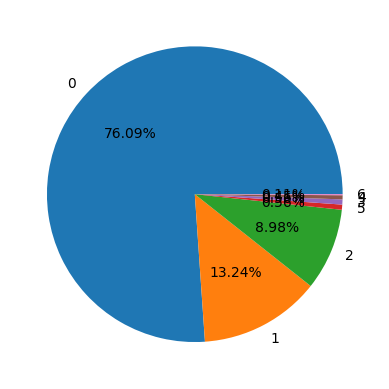

In [39]:
df['Parch'].value_counts().plot(kind = 'pie' , autopct ='%0.2f%%')

In [40]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

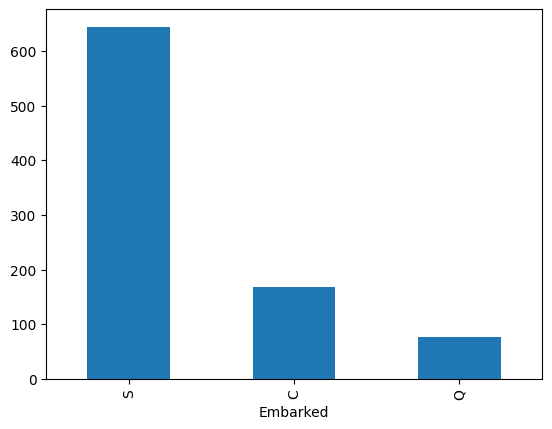

In [41]:
df['Embarked'].value_counts().plot(kind = 'bar' )

<Axes: >

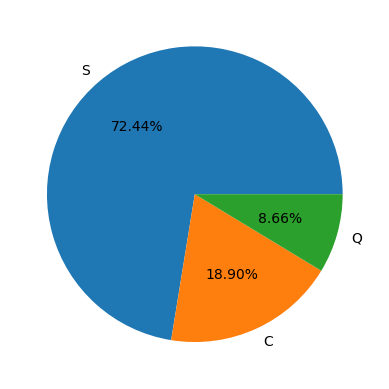

In [42]:
df['Embarked'].value_counts().plot(kind = 'pie' , autopct ='%0.2f%%')

### Mixed Columns 
- Need to feature engineer the mixed columns to get more informations (insights)


### Bivariate Analysis


 ### Survived and Pclass (Categorical - Categorical )
 **Conclusions**
 - %age of people survived is higher in higher class.

In [43]:
pd.crosstab(df['Survived'],df['Pclass'] , normalize='columns')*100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

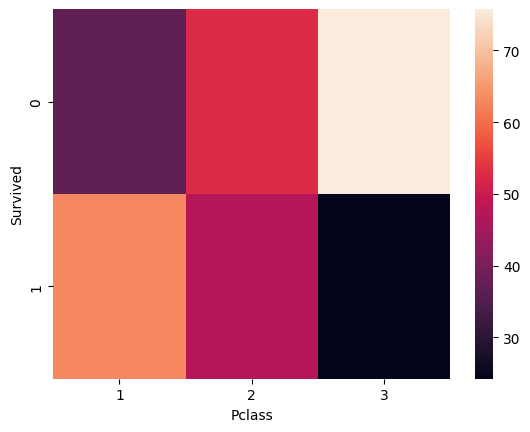

In [44]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'] , normalize='columns')*100)

 ### Survived and Sex (Categorical - Categorical )
 **Conclusions**
 - Females survived more than males.

In [45]:
pd.crosstab(df['Survived'],df['Sex'] , normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


 ### Survived and Age (Cat - Num )
 **Conclusions** 
 - Survivors were slightly younger on average compared to non-survivors.
 - Young children had relatively higher survival rates.
 - A few elderly passengers existed and appear as outliers in the age distribution.

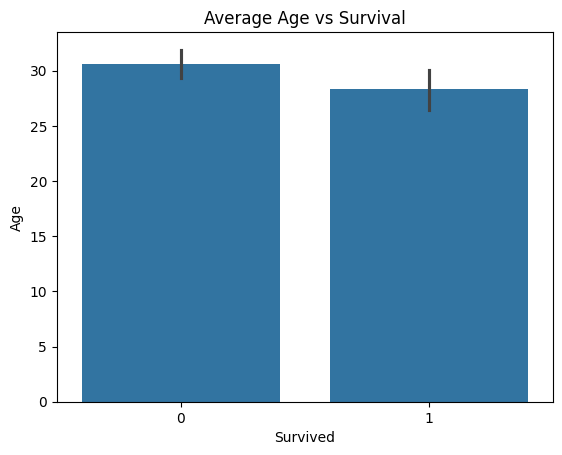

In [46]:
sns.barplot(x='Survived', y='Age', data=df)

plt.title("Average Age vs Survival")
plt.show()

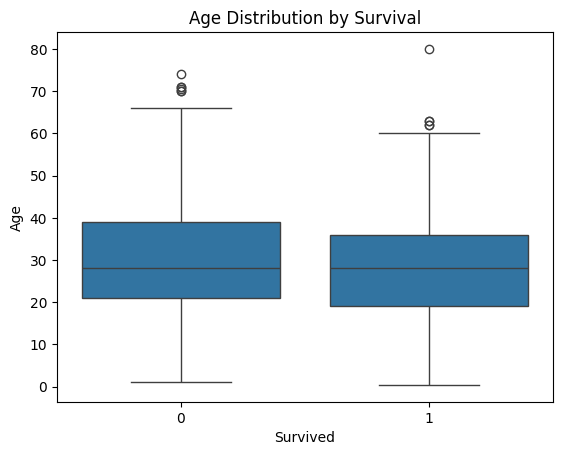

In [47]:
sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.show()

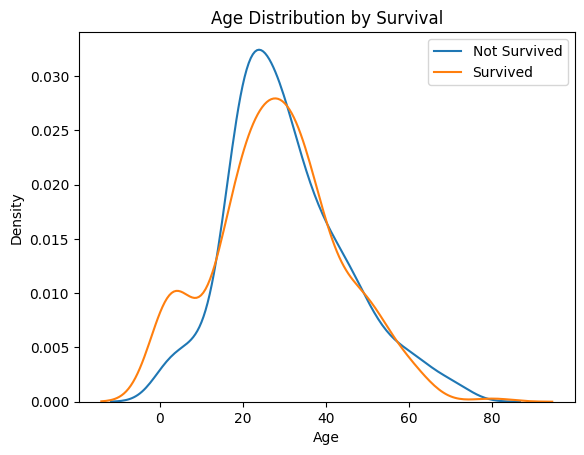

In [48]:
# KDE PLOT
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Not Survived' )

sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Survived')

plt.title("Age Distribution by Survival")
plt.legend()
plt.show()

 ### Survived and Embarked (Cat - Cat )
**Conclusion**
- More than half of the passengers embarking from Cherbourg belonged to first class.
- Almost all passengers boarding from Queenstown were third-class passengers.
- Southampton had a majority of third-class passengers, contributing to its relatively low survival rate.
- Cherbourg (C) had the highest survival rate because over 50% of its passengers belonged to first class, whereas Queenstown (Q) and Southampton (S) were dominated by third-class passengers.

In [49]:
pd.crosstab(df['Survived'],df['Embarked'] , normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [50]:
pd.crosstab(df['Pclass'],df['Embarked'] , normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


In [51]:
pd.crosstab(df['Sex'],df['Embarked'] , normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


### Feature Engineering on Fare


In [52]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [53]:
df[df['SibSp']==8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [54]:
df1 = pd.read_csv("sample_data/test.csv")

In [55]:
df = pd.concat([df,df1])

In [56]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [57]:
df[df['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


In [58]:
df['individual_fare'] = df['Fare']/(df['SibSp'] + df['Parch'] +1)

In [59]:
df[['individual_fare' , 'Fare']].describe()

,individual_fare,Fare
count,1308.000000,1308.000000
mean,20.518215,33.295479
std,35.774337,51.758668
min,0.000000,0.000000
25%,7.452767,7.895800
50%,8.512483,14.454200
75%,24.237500,31.275000
max,512.329200,512.329200


In [60]:
df['family_size']=(df['SibSp'] + df['Parch'] +1)

In [61]:
# family_type
# 1 -> alone
# 2-4 -> small
# >5 -> large


def transform_family_size(num):
    if num ==1:
        return 'alone'
    elif num > 1 and num < 5:
        return "small"
    else:
        return "large"

In [62]:
df['family_type'] = df['family_size'].apply(transform_family_size)

In [63]:
df = df.reset_index(drop=True)

In [64]:
pd.crosstab(df['Survived'], df['family_type'], normalize='columns') * 100

family_type,alone,large,small
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


In [65]:
df['surname']=df['Name'].str.split(',').str.get(0)

In [66]:
df['title']=df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [67]:
df['title'].value_counts()

title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Ms.            2
Major.         2
Mlle.          2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [68]:
### replace the frequncy <10 -> other
title_counts = df['title'].value_counts()

rare_titles = title_counts[title_counts < 10].index

df['title'] = df['title'].replace(rare_titles, 'Other')

In [69]:
df['title'].value_counts()

title
Mr.        757
Miss.      260
Mrs.       197
Master.     61
Other       34
Name: count, dtype: int64

In [70]:
pd.crosstab(df['Survived'], df['title'], normalize='columns') * 100

title,Master.,Miss.,Mr.,Mrs.,Other
Survived,,,,,
0.0,42.5,30.21978,84.332689,20.8,55.555556
1.0,57.5,69.78022,15.667311,79.2,44.444444


In [71]:
df['Cabin'].isnull().sum() / len(df['Cabin']) *100
#percentage of missing values in cabin

np.float64(77.46371275783041)

In [93]:
df['Cabin'].value_counts().head(15)

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F2                 4
F4                 4
C78                4
D                  4
C22 C26            4
B96 B98            4
B58 B60            3
E101               3
E34                3
A34                3
C101               3
Name: count, dtype: int64

In [97]:
df['Cabin'] = df['Cabin'].fillna('M')
## fill missing values with 'M' for missing

In [99]:
df['deck'] = df['Cabin'].str[0]

In [105]:
pd.crosstab(df['deck'], df['Pclass'], normalize='columns') * 100
# percentage of passengers in class per deck

Pclass,1,2,3
deck,,,
A,6.811146,0.000000,0.000000
B,20.123839,0.000000,0.000000
C,29.102167,0.000000,0.000000
D,12.383901,2.166065,0.000000
E,10.526316,1.444043,0.423131
F,0.000000,4.693141,1.128350
G,0.000000,0.000000,0.705219
M,20.743034,91.696751,97.743300
T,0.309598,0.000000,0.000000


In [106]:
pd.crosstab(df['Survived'], df['deck'], normalize='columns') * 100

deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0.0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1.0,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


<Axes: xlabel='deck'>

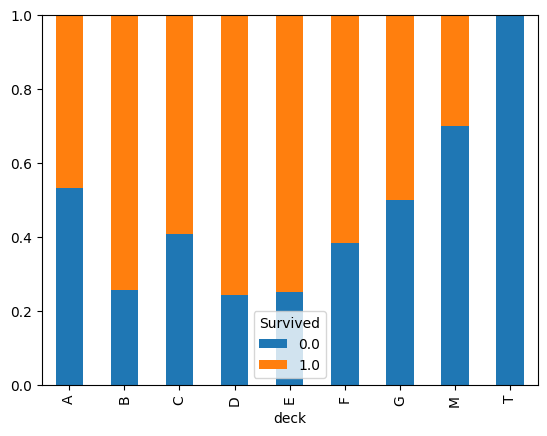

In [109]:
pd.crosstab( df['deck'],df['Survived'], normalize='index').plot(kind='bar', stacked=True)

In [111]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,individual_fare,family_size
PassengerId,1.000000,-0.005007,-0.038354,0.028814,-0.055224,0.008942,0.031428,0.035365,-0.031437
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.221600,0.016639
Pclass,-0.038354,-0.338481,1.000000,-0.408106,0.060832,0.018322,-0.558629,-0.504270,0.050027
Age,0.028814,-0.077221,-0.408106,1.000000,-0.243699,-0.150917,0.178740,0.193545,-0.240229
SibSp,-0.055224,-0.035322,0.060832,-0.243699,1.000000,0.373587,0.160238,-0.089807,0.861952
Parch,0.008942,0.081629,0.018322,-0.150917,0.373587,1.000000,0.221539,-0.065498,0.792296
Fare,0.031428,0.257307,-0.558629,0.178740,0.160238,0.221539,1.000000,0.832029,0.226492
individual_fare,0.035365,0.221600,-0.504270,0.193545,-0.089807,-0.065498,0.832029,1.000000,-0.094874
family_size,-0.031437,0.016639,0.050027,-0.240229,0.861952,0.792296,0.226492,-0.094874,1.000000


In [112]:
df.corr(numeric_only=True)['Survived']

PassengerId       -0.005007
Survived           1.000000
Pclass            -0.338481
Age               -0.077221
SibSp             -0.035322
Parch              0.081629
Fare               0.257307
individual_fare    0.221600
family_size        0.016639
Name: Survived, dtype: float64

<Axes: >

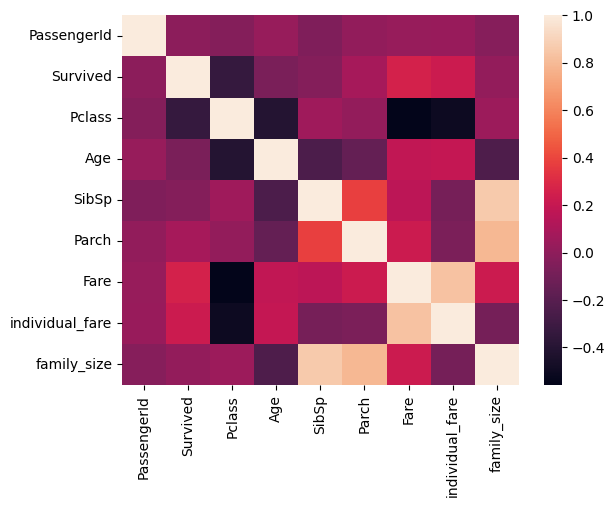

In [ ]:
sns.heatmap(df.corr(numeric_only=True))

# if two columns are highly correlated, we use one generally.
# Highly correlated columns are like: two friends telling you almost the same story.

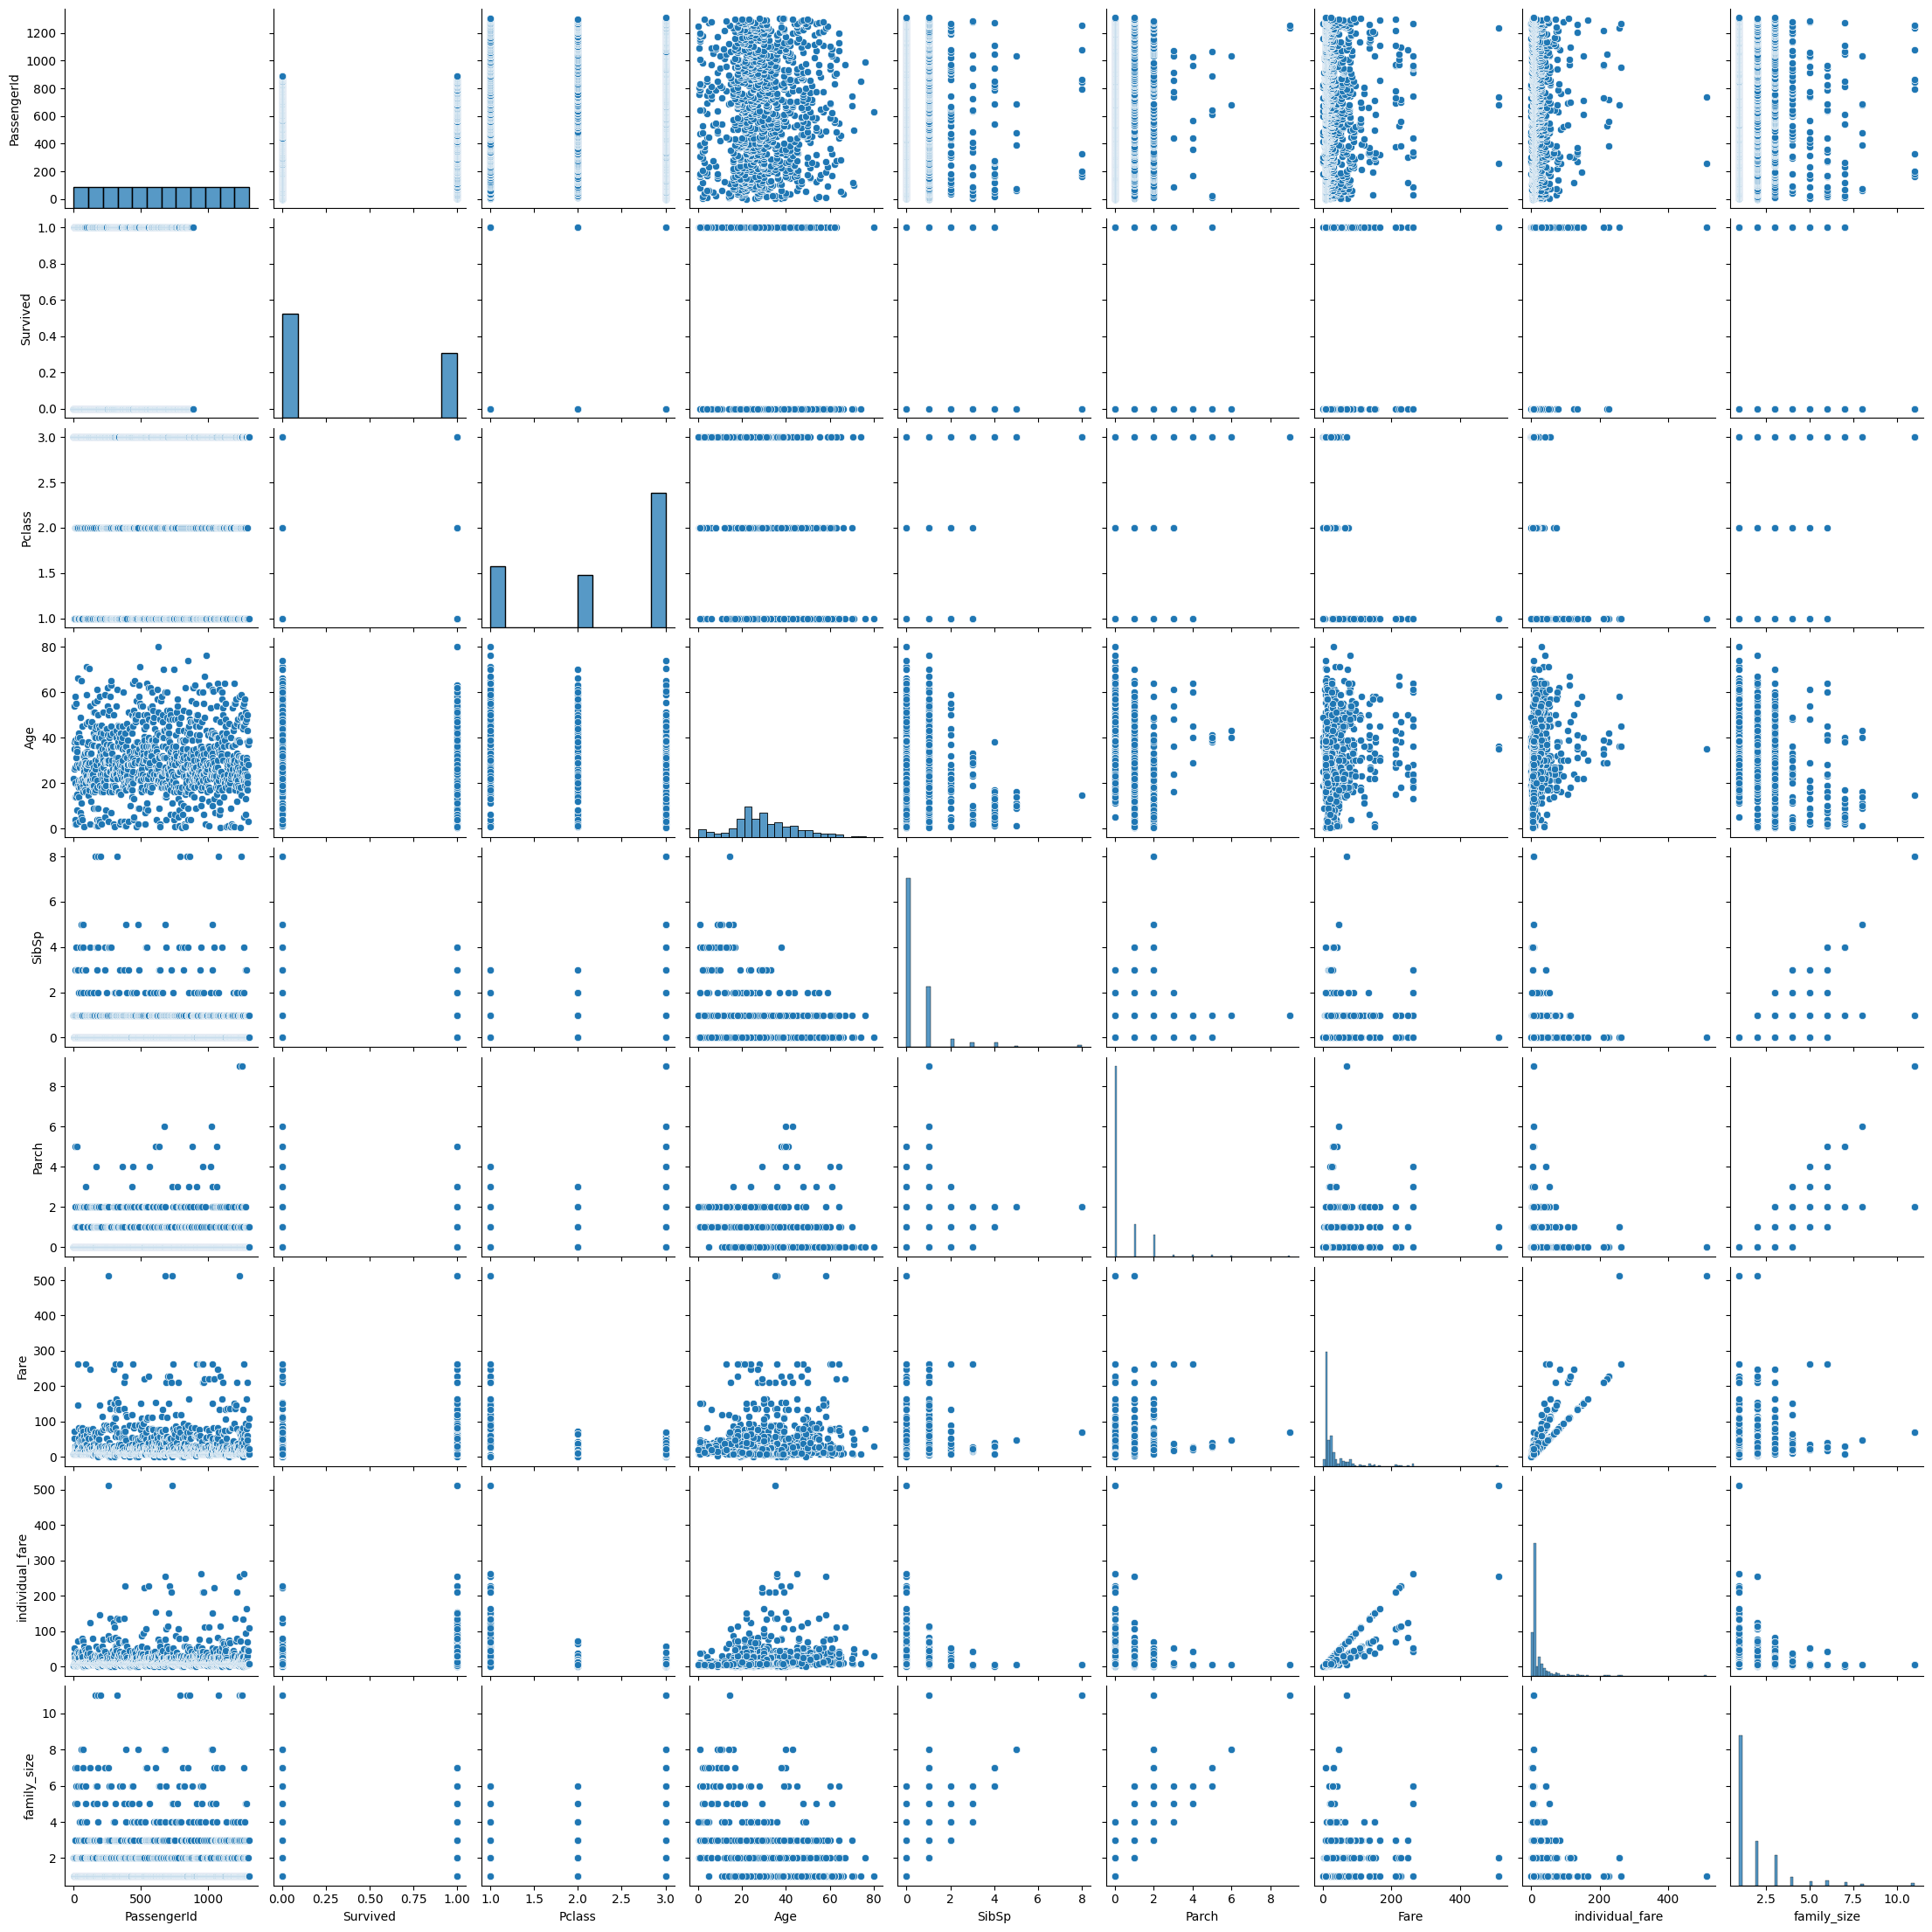

In [114]:
sns.pairplot(df)

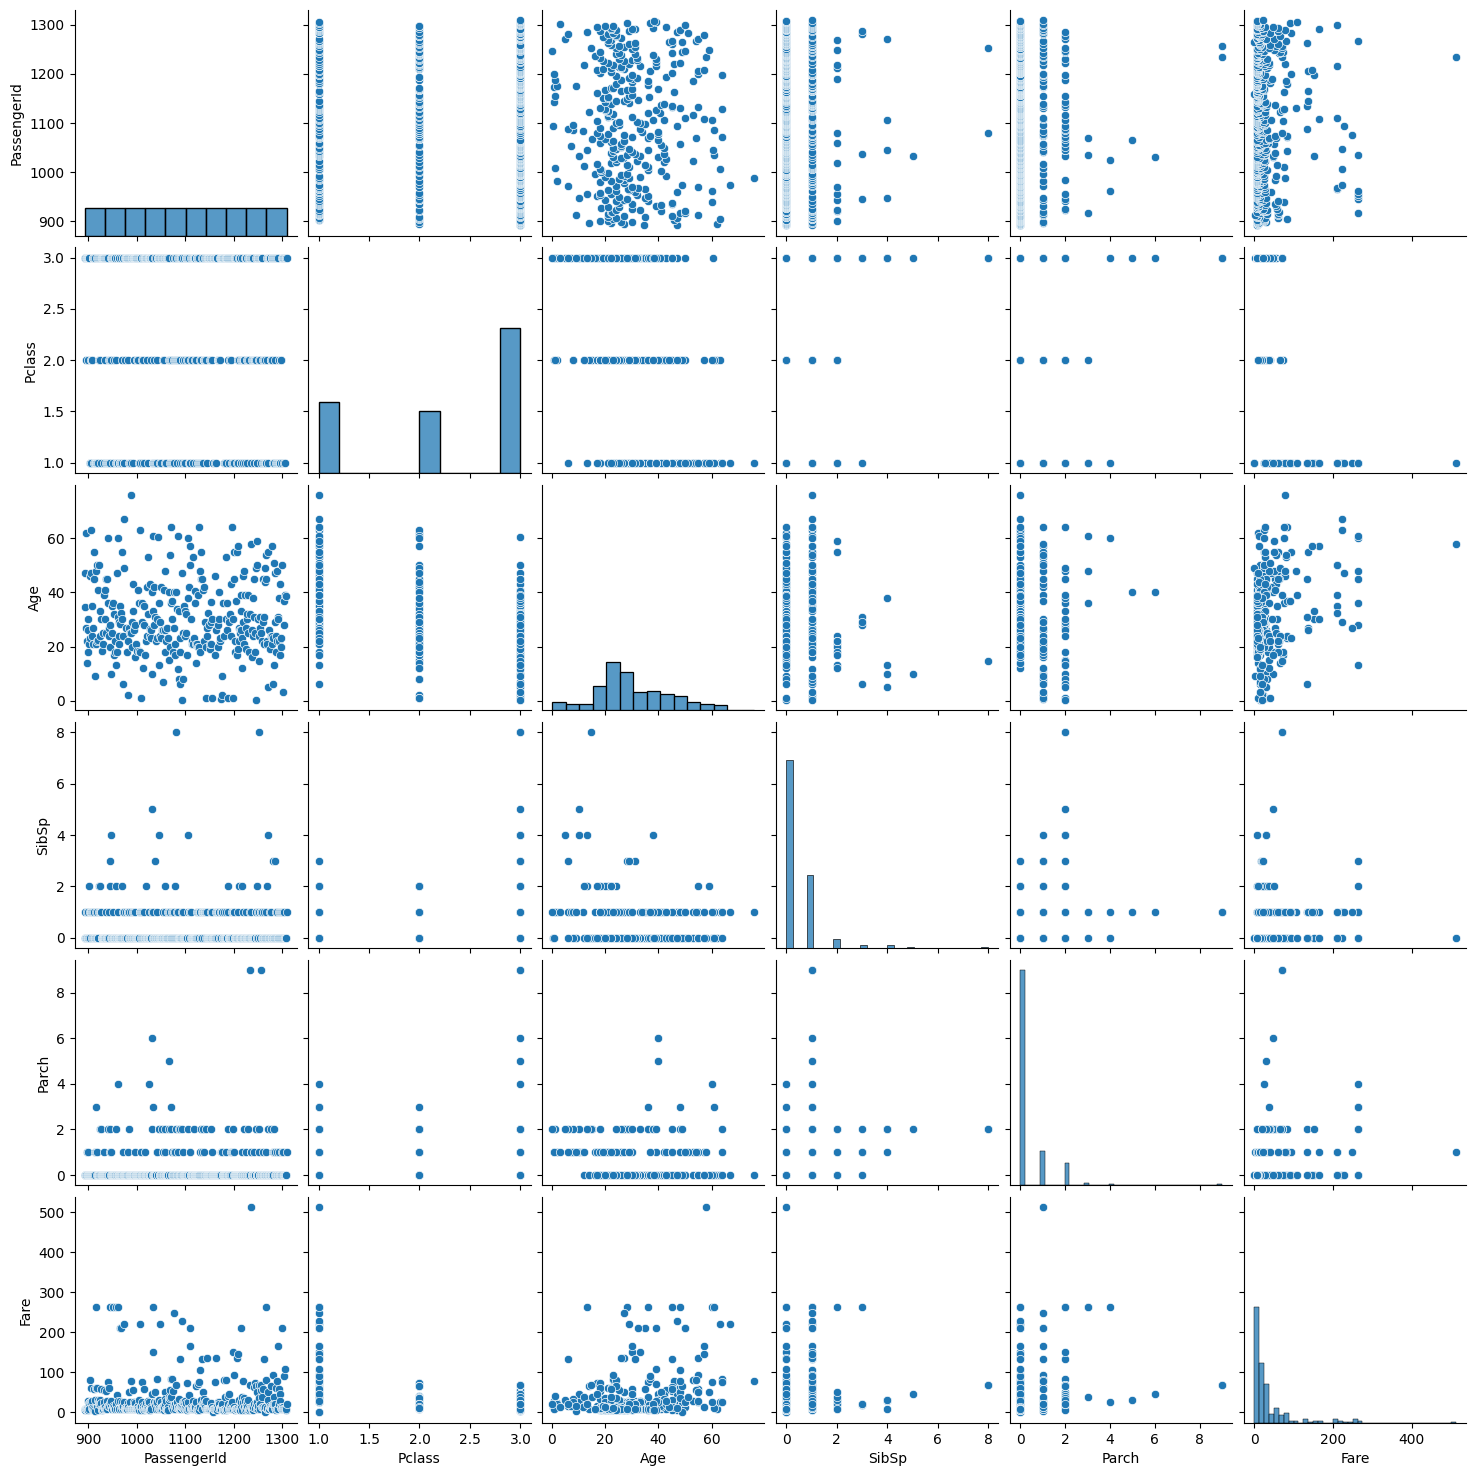

In [115]:
sns.pairplot(df1)